# PPCC Plot (Probability Plot Correlation Coefficient)

The **PPCC Plot** identifies the best-fitting member of a distribution family by scanning the shape parameter and computing the probability plot correlation coefficient at each value. The peak of the PPCC curve identifies the shape parameter that produces the most linear Q-Q plot.

| Property | Value |
|---|---|
| **Purpose** | Select optimal shape parameter for a distribution family |
| **X-axis** | Shape parameter value (scanned over a range) |
| **Y-axis** | Pearson r between sorted data and theoretical quantiles |
| **Peak** | Best-fitting shape parameter |
| **Families** | Weibull (γ), Tukey-Lambda (λ), Johnson, logistic, etc. |
| **Use after** | Initial 4-plot suggests a specific distribution family |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

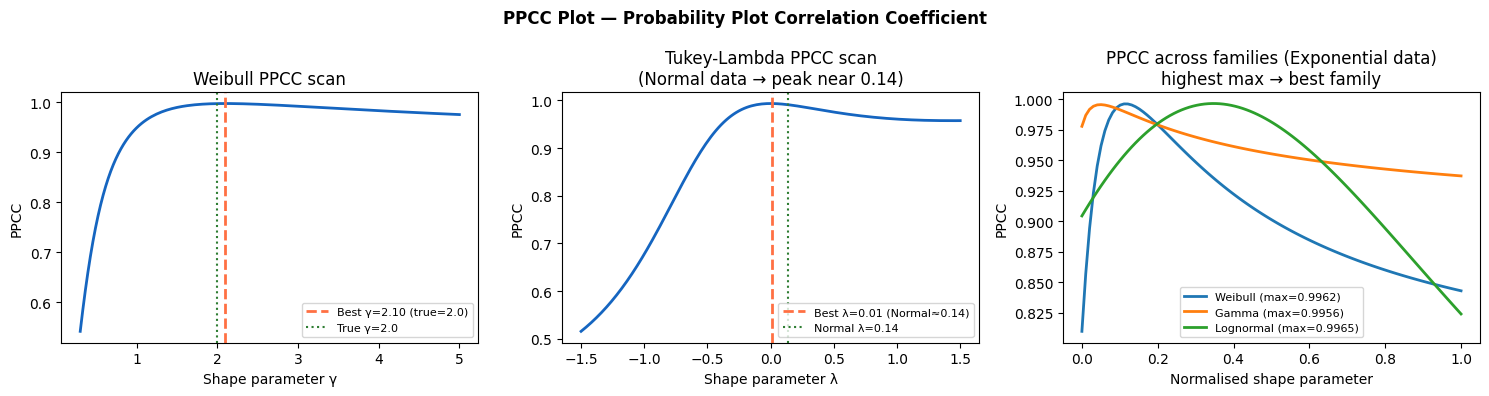

Best shape parameters (Exponential data):
  Weibull     : best param=0.822, max PPCC=0.9962
  Gamma       : best param=0.689, max PPCC=0.9956
  Lognormal   : best param=0.753, max PPCC=0.9965


In [2]:
def ppcc_scan(data, dist_frozen_fn, params, n_points=200):
    n = len(data)
    sorted_data = np.sort(data)
    # Filliben's plotting position
    i = np.arange(1, n+1)
    pp = (i - 0.375) / (n + 0.25)
    pp[0] = 1 - 0.5**(1/n)
    pp[-1] = 0.5**(1/n)
    correlations = []
    for p in params:
        try:
            theoretical = dist_frozen_fn(p).ppf(pp)
            if np.any(np.isinf(theoretical)) or np.any(np.isnan(theoretical)):
                correlations.append(np.nan)
            else:
                correlations.append(np.corrcoef(sorted_data, theoretical)[0, 1])
        except Exception:
            correlations.append(np.nan)
    return np.array(correlations)

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PPCC Plot — Probability Plot Correlation Coefficient', fontsize=12, fontweight='bold')

# Weibull PPCC scan
gammas = np.linspace(0.3, 5.0, 150)
data_weibull = stats.weibull_min(c=2.0).rvs(200)  # true shape = 2
ppcc_w = ppcc_scan(data_weibull, lambda g: stats.weibull_min(c=g), gammas)
best_g = gammas[np.nanargmax(ppcc_w)]
axes[0].plot(gammas, ppcc_w, color='#1565C0', lw=2)
axes[0].axvline(best_g, color='#FF7043', lw=2, ls='--', label=f'Best γ={best_g:.2f} (true=2.0)')
axes[0].axvline(2.0, color='#2E7D32', lw=1.5, ls=':', label='True γ=2.0')
axes[0].set_title('Weibull PPCC scan')
axes[0].set_xlabel('Shape parameter γ'); axes[0].set_ylabel('PPCC')
axes[0].legend(fontsize=8)

# Tukey-Lambda PPCC scan (Normal data → peak near 0.14)
lambdas = np.linspace(-1.5, 1.5, 150)
data_normal = stats.norm.rvs(size=200)
def tukey_ppf_fn(lam):
    class _dist:
        def ppf(self, p):
            if abs(lam) < 1e-8:
                return np.log(p/(1-p))
            return (p**lam - (1-p)**lam) / lam
    return _dist()
ppcc_tl = ppcc_scan(data_normal, tukey_ppf_fn, lambdas)
best_l = lambdas[np.nanargmax(ppcc_tl)]
axes[1].plot(lambdas, ppcc_tl, color='#1565C0', lw=2)
axes[1].axvline(best_l, color='#FF7043', lw=2, ls='--', label=f'Best λ={best_l:.2f} (Normal≈0.14)')
axes[1].axvline(0.14, color='#2E7D32', lw=1.5, ls=':', label='Normal λ=0.14')
axes[1].set_title('Tukey-Lambda PPCC scan\n(Normal data → peak near 0.14)')
axes[1].set_xlabel('Shape parameter λ'); axes[1].set_ylabel('PPCC')
axes[1].legend(fontsize=8)

# Compare PPCC max across three distribution families for the same dataset
data_exp = stats.expon.rvs(size=200)
families = {
    'Weibull': (np.linspace(0.3, 5.0, 100), lambda g: stats.weibull_min(c=g)),
    'Gamma': (np.linspace(0.3, 8.0, 100), lambda a: stats.gamma(a=a)),
    'Lognormal': (np.linspace(0.1, 2.0, 100), lambda s: stats.lognorm(s=s)),
}
results = {}
for name, (params, fn) in families.items():
    ppcc_vals = ppcc_scan(data_exp, fn, params)
    results[name] = (params[np.nanargmax(ppcc_vals)], np.nanmax(ppcc_vals))
    axes[2].plot(np.linspace(0, 1, len(params)), ppcc_vals,
                 lw=2, label=f'{name} (max={np.nanmax(ppcc_vals):.4f})')
axes[2].set_title('PPCC across families (Exponential data)\nhighest max → best family')
axes[2].set_xlabel('Normalised shape parameter'); axes[2].set_ylabel('PPCC')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

print('Best shape parameters (Exponential data):')
for name, (best_p, best_r) in results.items():
    print(f'  {name:12s}: best param={best_p:.3f}, max PPCC={best_r:.4f}')

## Key Takeaways

| | |
|---|---|
| **PPCC peak** | The shape parameter value that makes the Q-Q plot most linear |
| **Value near 1.0** | Near-perfect fit — data follows that member of the family |
| **Compare families** | Run PPCC on multiple families; highest peak → best overall family |
| **Weibull γ** | γ=1 → Exponential, γ≈3.5 → Normal-like, γ<1 → heavy left tail |
| **Tukey-Lambda λ** | λ=0.14 → Normal, λ=0 → Logistic, λ=−1 → Cauchy |
| **Filliben positions** | Use (i−0.375)/(n+0.25) as plotting positions for best results |
| **After PPCC** | Confirm with Anderson-Darling or KS goodness-of-fit test |